In [1]:
%matplotlib inline
import internal_script

import numpy as np

#CD Please avoid import *
#CD The exception being chXX_some_chapter, that will typically start with "from some_chapter import *"
#CD cf. the README.md
#from dorion_francois.plot_utils import *
from dorion_francois.instruments import Bond, Spot, Call, Put, DownAndOutPut, DigitalCall, DigitalPut
from dorion_francois.plot_utils import (mpl, plt, mtick, mdates, gridspec,
                                        set_plt_defaults, set_payoff_axes, set_time_axis, styles, with_style)

# Defining these here so that all graphs are anchored around the same level
S_0 = 100
#S_T = np.arange(0.35, 1.50, 0.01)*S_0
#xlims = [30, 155]
S_T = np.arange(0.25, 1.65, 0.01)*S_0
xlims = [35, 170]
def plot_underlying():    
    ax.plot(xlims, xlims, **styles['gridlines'])

## NBC1155, Recovery Note Securities linked to the S&P/TSX 60 Index Series 4 
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=600

Down and out put option ($K=100, H=65$) + underlying asset (S&P/TSX 60 Index) 

Path dependence:
* If the put is alive: 
    | Terminal value   | Payoff |
    |------------------|--------|
    | H < S(T) $\le$ K | K      |
    | K < S(T).        | S      |
    
* If knocked out: Payoff = S(T)

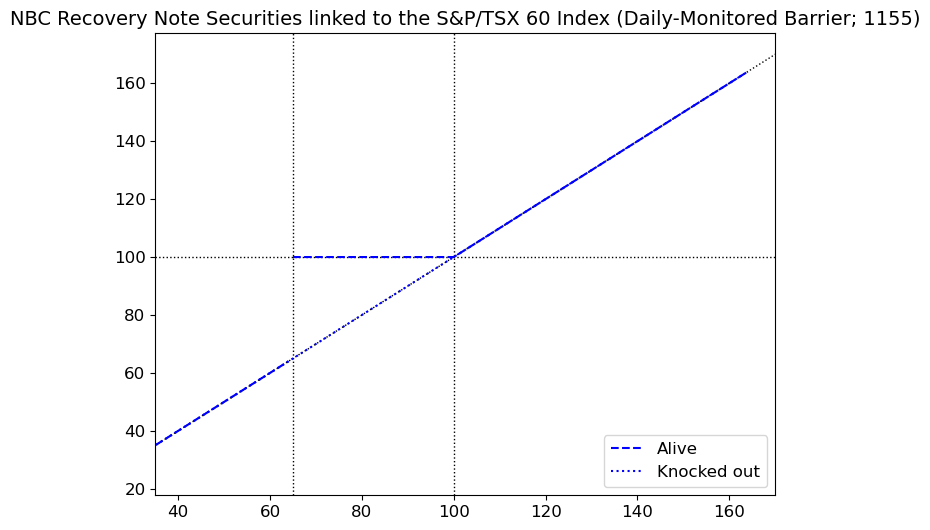

In [2]:
K = S_0
H = 0.65*S_0
T = 3

# A structured producted is often referred to as a "note"
note = DownAndOutPut(S_0, K, H) + Spot(S_0)

# The down and out put is path dependent. These "paths" have an initial row at S_0 and, for simplicity an
# "intermediate" time step, also at S_0 > H.
S_0_t = np.array([S_0, S_0]).reshape(-1,1)
note.update_history(S_0_t)

# This alternate set of "paths" all cross H at the intermediate date 
note_out = DownAndOutPut(S_0, K, H) + Spot(S_0)
S_0_t = np.array([S_0, H-1]).reshape(-1,1)
note_out.update_history(S_0_t)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Recovery Note Securities linked to the S&P/TSX 60 Index (Daily-Monitored Barrier; 1155)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position1']) # highlight the discontinuity
ax.plot(S_T[S_T>H], payoff[S_T>H], **with_style('Alive', 'position1')) 

ax.plot(S_T, note_out.payoff(S_T), **with_style('Knocked out', 'position2'))
ax.legend(loc='lower right');
ax.set_xlim(xlims);

## V75863, NBC Recovery Note Securities linked to the S&P/TSX 60 Index S1
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=625

Down and out put option ($K=100, L=65$) 
+ underlying asset (S&P/TSX 60 Index) 
- call option with strike $H=150$

Path dependence:
* If the put is alive: 
    | Terminal value   | Payoff |
    |------------------|--------|
    | L < S(T) $\le$ K | K      |
    | K < S(T) < H     | S      |
    | H $\le$ S(T)     | H      |
    
* If knocked out:
    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) < H         | S      |
    | H $\le$ S(T)     | H      |

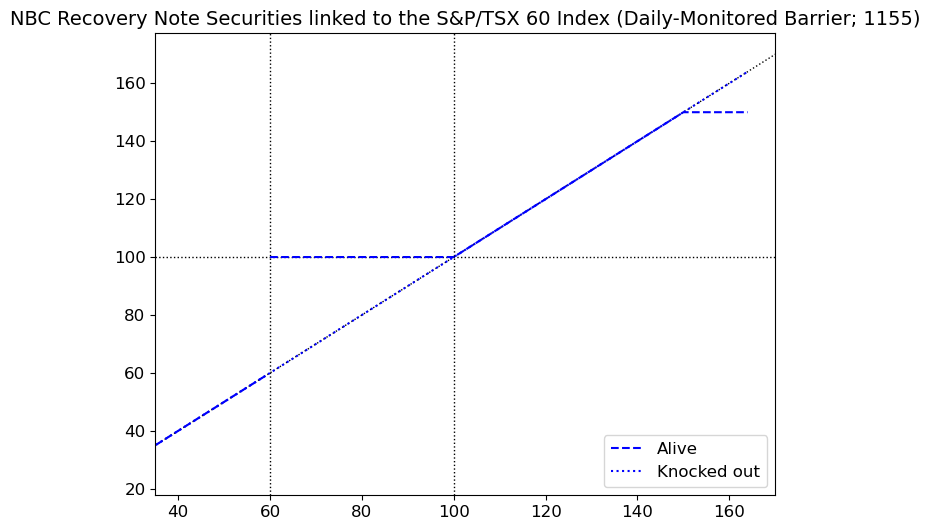

In [3]:
K = S_0
L = 0.6*S_0
H = 1.5*S_0
T = 2

# # Extend graph to show cap
# S_T = np.arange(0.25, 1.65, 0.01)*S_0
# xlims = [35, 170]

# A structured producted is often referred to as a "note"
note = DownAndOutPut(S_0, K, L) + Spot(S_0) - Call(S_0, H)

# The down and out put is path dependent. These "paths" have an initial row at S_0 and, for simplicity an
# "intermediate" time step, also at S_0 > L.
S_0_t = np.array([S_0, S_0]).reshape(-1,1)
note.update_history(S_0_t)

# This alternate set of "paths" all cross L at the intermediate date 
note_out = DownAndOutPut(S_0, K, L) + Spot(S_0)
S_0_t = np.array([S_0, L-1]).reshape(-1,1)
note_out.update_history(S_0_t)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Recovery Note Securities linked to the S&P/TSX 60 Index (Daily-Monitored Barrier; 1155)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(L, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=L], payoff[S_T<=L], **styles['position1']) # highlight the discontinuity
ax.plot(S_T[S_T>L], payoff[S_T>L], **with_style('Alive', 'position1')) 

ax.plot(S_T, note_out.payoff(S_T), **with_style('Knocked out', 'position2'))
ax.legend(loc='lower right');
ax.set_xlim(xlims);

# # Revert to more compact graph
# S_T = np.arange(0.35, 1.50, 0.01)*S_0
# xlims = [30, 155]

## NBC1280, NBC Marathon Note Securities (Maturity-Monitored Barrier) linked to the units of the iShares® S&P/TSX 60
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1167


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S    |
    | H< S(T) $\le$ S_0 | S_0    |
    | S(T)>S_0.          | AF*S     |
    

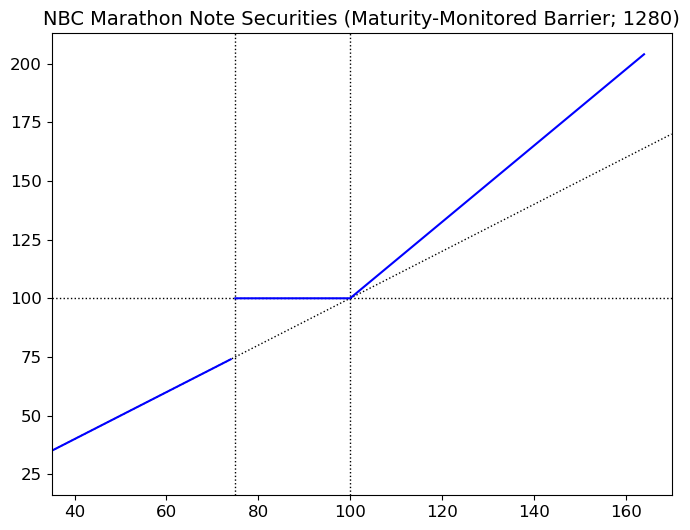

In [4]:

K = S_0
H = 0.75*S_0
T = 5
AF = 1.625 # Accelaration Factor

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) - (K-H)*DigitalPut(np.nan, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon Note Securities (Maturity-Monitored Barrier; 1280)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position']) # highlight the discontinuity
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);


## NBC1282, NBC Marathon Note Securities (Partial Protection) linked to the units of the iShares® S&P/TSX 60 Index ETF
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1170


* Payoff table: 
    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | H*S_0      |
    | H < S(T) $\le$ K | S      |
    | S(T)>K.          | S+(AF-1)*(S-S_0)      |
    

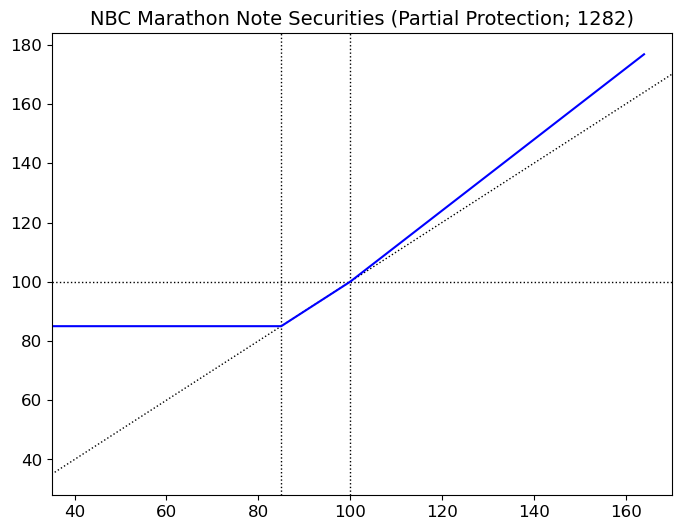

In [5]:

K = S_0
H = 0.85*S_0
T = 5
AF = 1.2

note = Spot(S_0) + Put(S_0, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon Note Securities (Partial Protection; 1282)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);


## NBC2709, NBC Bonus TwoStep Note Securities (Maturity-Monitored Barrier) linked to the units of the iShares® S&P/TSX 60 Index ETF

https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1188


* Payoff table: 
    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S      |
    | H < S(T) $\le$ S_0 | S_0      |
    | S_0 < S(T) $\le$ S_0*(1+bonus) | S_0*(1+bonus)      |
    | S(T)>S_0*(1+bonus).          | S_0*(1+bonus+AF*((S-S_0)/S_0-Bonus))=S, AF=1      |
    

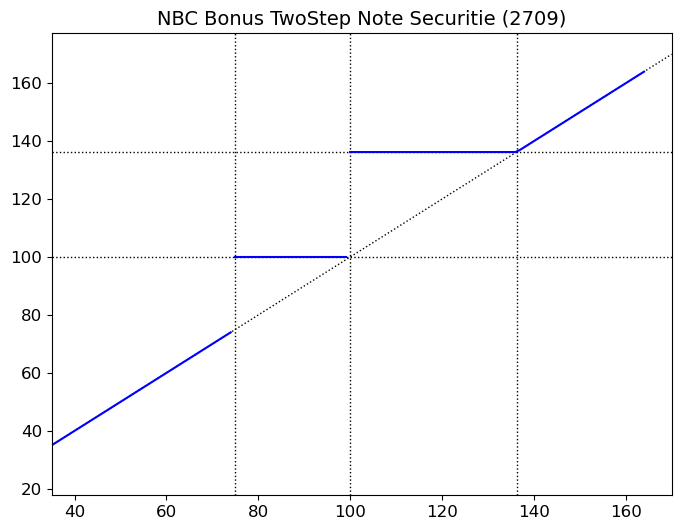

In [6]:

K = S_0
H = 0.75*S_0
T = 5.5
Bonus = 0.3625
K_1 = S_0*(1+Bonus)

note = K*DigitalPut(np.nan, K) - Put(S_0, H) - (K-H)*DigitalPut(np.nan, H) + K_1*DigitalCall(np.nan, K) + Call(S_0, K_1)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Bonus TwoStep Note Securitie (2709)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axhline(K_1, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])
ax.axvline(K_1, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position']) # highlight the discontinuity
ax.plot(S_T[(S_T<=K)&(S_T>H)], payoff[(S_T<=K)&(S_T>H)], **styles['position']) # highlight the discontinuity
ax.plot(S_T[S_T>K], payoff[S_T>K], **styles['position']);
ax.set_xlim(xlims);

## NBC1069, NBC Trekking Note Securities (Twin Win) linked to the units of the iShares® S&P/TSX 60 Index ETF

https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1189


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S    |
    | H< S(T) $\le$ S_0 | S_0*(TW*(-(S-S_0)/S_0))   |
    | S_0 < S(T) $\le$ S_0*(1+MR) | S  |
    | S(T)>S_0*(1+MR).          | S_0*(1+MR)    |
    

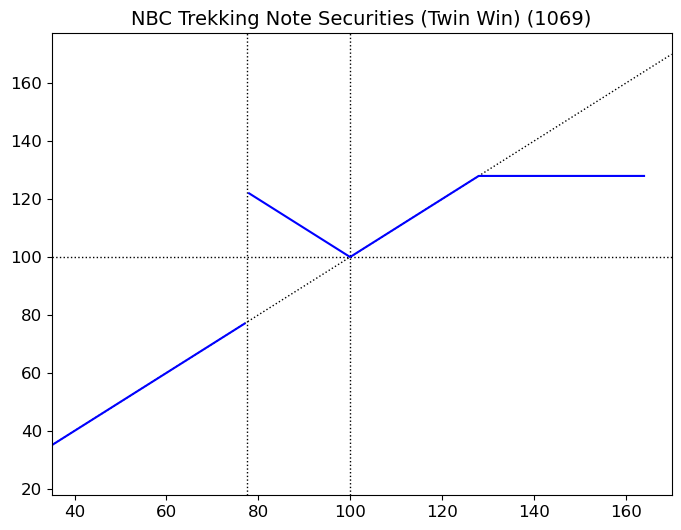

In [7]:

K = S_0
H = (1-0.2250)*S_0
MR = 0.28
T = 3.5
TW = 1

note = Spot(S_0) + (1+TW)*Put(S_0, K) - (1+TW)*Put(S_0, H) - (1+TW)*(K-H)*DigitalPut(np.nan, H) - Call(S_0, (1+MR)*K) 

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Trekking Note Securities (Twin Win) (1069)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position']) # highlight the discontinuity
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);

# NBC1861 NBC iShares® S&P/TSX 60 Index ETF Deposit Notes S1
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1242

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ K    | S_0   |
    | S(T)>K          | PF*S  |

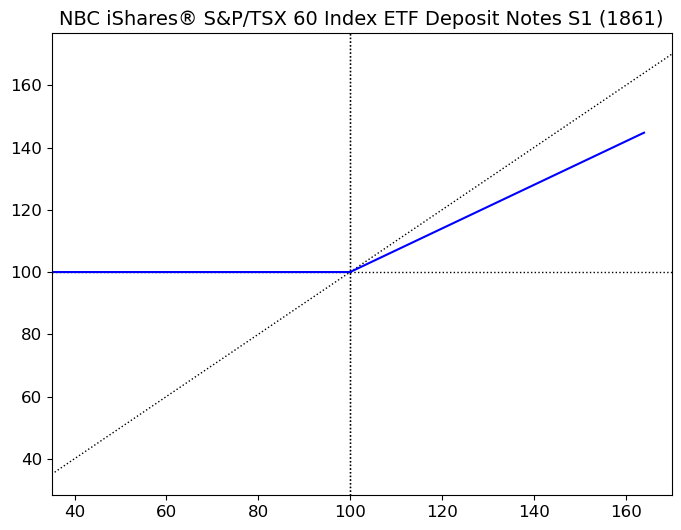

In [8]:

K = S_0
# K should be arithmetic average (expressed as a percentage and rounded to two decimal places) 
# of the price return of the Reference Shares over the period starting on the Issue Date of 
# # the NBC iShares® S&P/TSX 60 Index ETF Deposit Notes and ending on the Valuation Date.
H = (1-0)*S_0
T = 5
PF = 0.7

note = Spot(S_0) - (1-PF)*Call(S_0, K) + Put(S_0, K)    

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC iShares® S&P/TSX 60 Index ETF Deposit Notes S1 (1861)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

# NBC1762  NBC Fixed ROC Note Securities (Maturity-Monitored Barrier) linked to the units of the iShares® S&P/TSX 60 Index ETF
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1297

# NBC1762 NBC1778
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1297 \\
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1723

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S + coupon   |
    | H< S(T) $\le$ S_0 | S_0  + coupon  |
    | S_0< S(T) $\le$ S_0*(1+RT)          | S_0*(1+RT) +coupon, RT=0  |
    | S(T)>S_0*(1+RT)  .          | S_0+PF*(S-S_0) + coupon    |

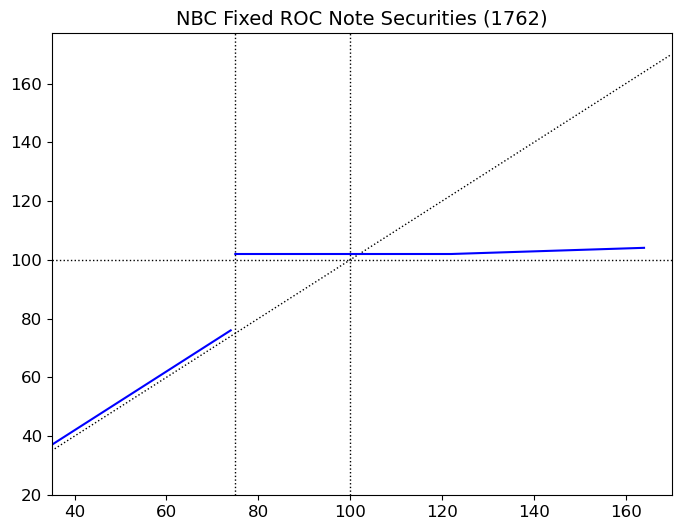

In [9]:

H = (1-0.25)*S_0
T = 5.5
PF = 0.05
RT = 0.22
K_1 = S_0
K_2 = (1+RT)*S_0
T_1 = 0.5
ROC = 2

note = Spot(S_0) + Put(S_0, K_1) - Put(S_0, H) - (K_1-H)*DigitalPut(np.nan, H) - Call(S_0, K_1) + PF*Call(S_0, K_2) + ROC*Bond(T)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Fixed ROC Note Securities (1762)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position'])
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);

## NBC1287, NBC Marathon Note Securities (Maturity-Monitored Barrier) linked to the units of the iShares® S&P/TSX 60 Index ETF

https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1308


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S    |
    | H< S(T) $\le$ S_0 | S_0    |
    | S(T)>S_0.          | AF*S     |
    

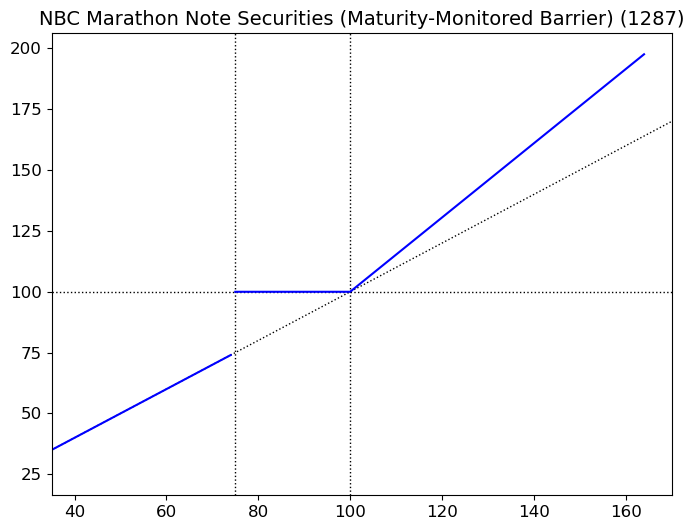

In [10]:

K = S_0
H = (1-0.25)*S_0
T = 5
AF = 1.525

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) - (K-H)*DigitalPut(np.nan, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon Note Securities (Maturity-Monitored Barrier) (1287)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position'])
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);

## NBC1288, NBC Marathon Note Securities (Buffered) linked to the units of the iShares® S&P/TSX 60 Index ETF

https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1331


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S+ S_0*buffer    |
    | H< S(T) $\le$ S_0 | S_0    |
    | S(T)>S_0.          | AF*S     |
    

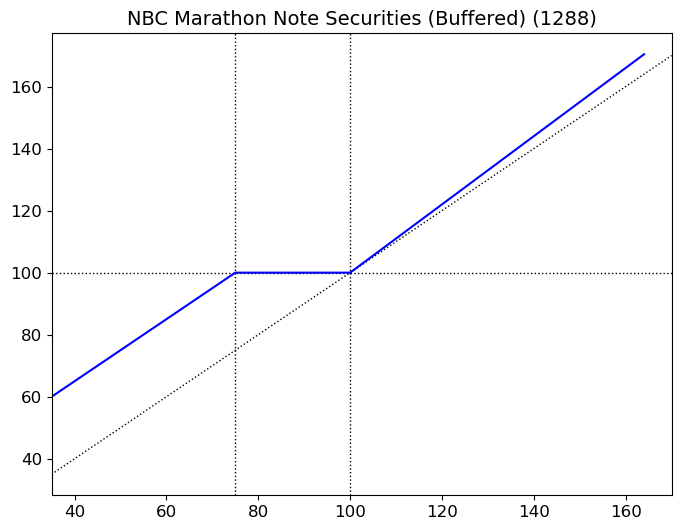

In [11]:

K = S_0
H = (1-0.25)*S_0
BF = 0.25
T = 5.5
AF = 1.10

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon Note Securities (Buffered) (1288)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

## NBC1681, NBC Bonus Note Securities (Maturity-Monitored Barrier) linked to the Canadian market

https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1413


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S    |
    | H< S(T) $\le$ S_0*(1+Booster return) | S_0*(1+Booster return)    |
    | S(T)>S_0*(1+Booster return) .          | PF*S     |
    

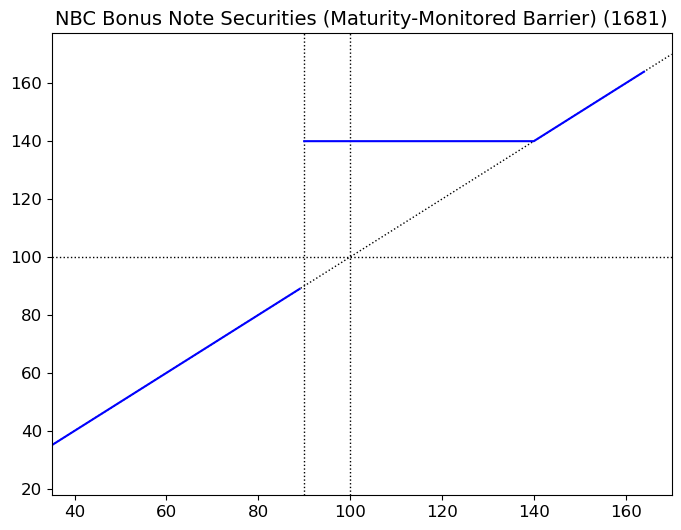

In [12]:

K = S_0
H = (1-0.1)*S_0
BR = 0.4
T = 5
PF = 1

note = Spot(S_0) + Put(S_0, (1+BR)*K) - Put(S_0, H) - ((1+BR)*K-H)*DigitalPut(np.nan, H) + (1-PF)*Call(S_0, (1+BR)*K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Bonus Note Securities (Maturity-Monitored Barrier) (1681)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position'])
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);

# NBC1869 NBC iShares® S&P/TSX 60 Index ETF Deposit Notes
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1318

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ K    | S_0   |
    | S(T)>K          | PF*S  |

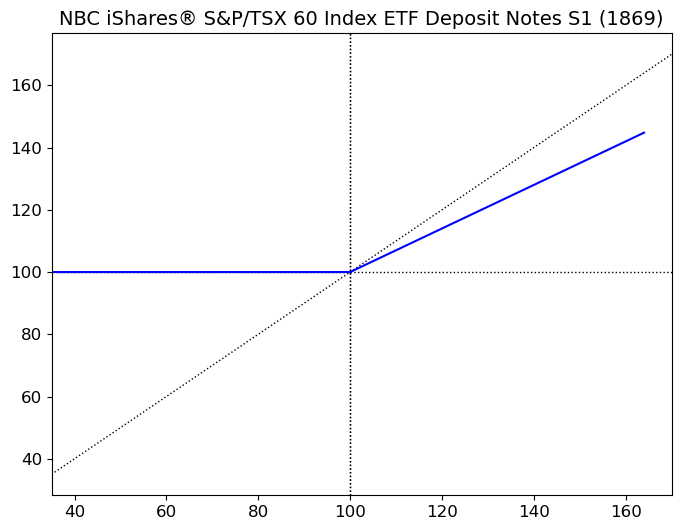

In [13]:

K = S_0 
# K should be arithmetic average (expressed as a percentage and rounded to two decimal places) 
# of the price return of the Reference Shares over the period starting on the Issue Date of 
# # the NBC iShares® S&P/TSX 60 Index ETF Deposit Notes and ending on the Valuation Date.
H = (1-0)*S_0
T = 5.5
PF = 0.7

note = Spot(S_0) - (1-PF)*Call(S_0, K) + Put(S_0, K) 

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC iShares® S&P/TSX 60 Index ETF Deposit Notes S1 (1869)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

## NBC2305, NBC Marathon Note Securities (Buffered) linked to the Canadian market

https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1671


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S+ S_0*buffer    |
    | H< S(T) $\le$ S_0 | S_0    |
    | S(T)>S_0.          | AF*S     |

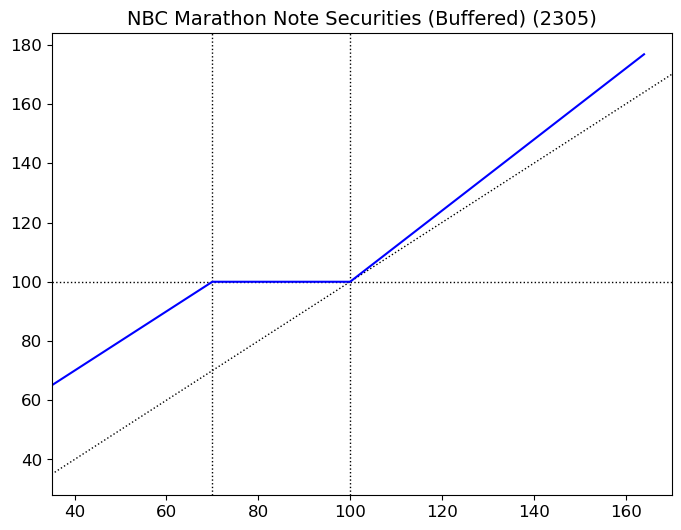

In [14]:
# NBC2305
# https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1671

K = S_0
H = (1-0.30)*S_0
BF = 0.30
T = 6
AF = 1.20

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon Note Securities (Buffered) (2305)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

# NBC2307 NBC Marathon Note Securities (Buffered) linked to the Canadian market
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1683

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S+ S_0*buffer    |
    | H< S(T) $\le$ S_0 | S_0    |
    | S(T)>S_0.          | AF*S     |

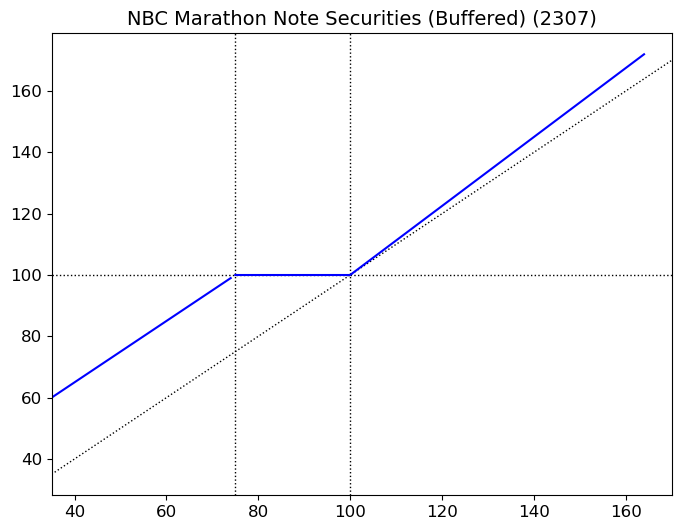

In [15]:


K = S_0
H = (1-0.25)*S_0
BF = 0.25
T = 5
AF = 1.125

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon Note Securities (Buffered) (2307)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position'])
ax.plot(S_T[S_T>H], payoff[S_T>H], **with_style('Alive', 'position'));
ax.set_xlim(xlims);

# NBC2317 NBC Marathon Note Securities (Maturity-Monitored Barrier)
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1859

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S    |
    | H< S(T) $\le$ S_0 | S_0    |
    | S(T)>S_0.          | AF*S     |

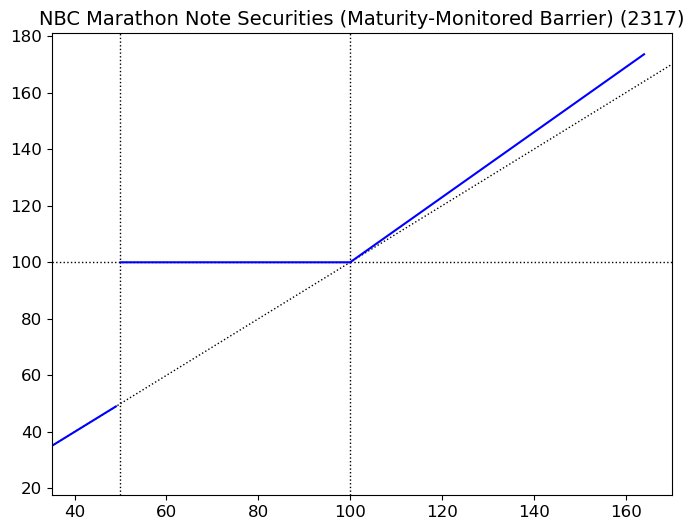

In [16]:


K = S_0
H = 0.50*S_0
T = 6
AF = 1.15

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) - (K-H)*DigitalPut(np.nan, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon Note Securities (Maturity-Monitored Barrier) (2317)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position'])
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);

# NBC2318, NBC Marathon Note Securities (Maturity-Monitored Barrier) 
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1873


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S    |
    | H< S(T) $\le$ S_0 | S_0    |
    | S(T)>S_0.          | AF*S     |

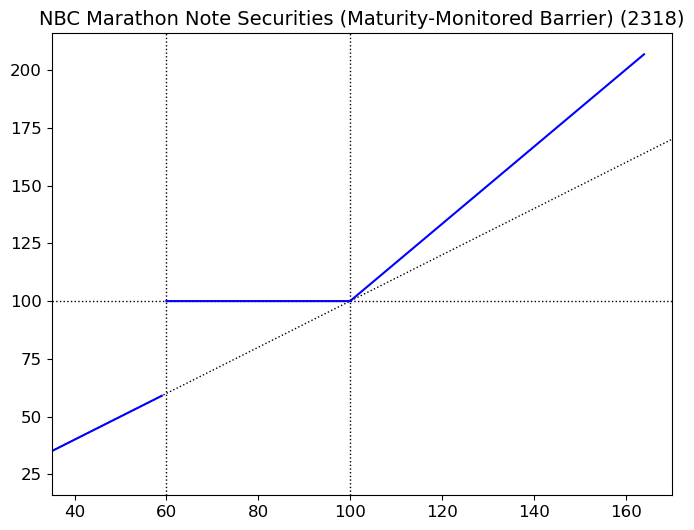

In [17]:
K = S_0
H = (1-0.4)*S_0
T = 6
AF = 1.67

note = note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) - (K-H)*DigitalPut(np.nan, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon Note Securities (Maturity-Monitored Barrier) (2318)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position'])
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);

# NBC2321, NBC Marathon™ Note Securities (No Barrier)
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1960
# NBC2324
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=1960


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ S_0     | S    |
    | S(T)>S_0.          | AF*S     |


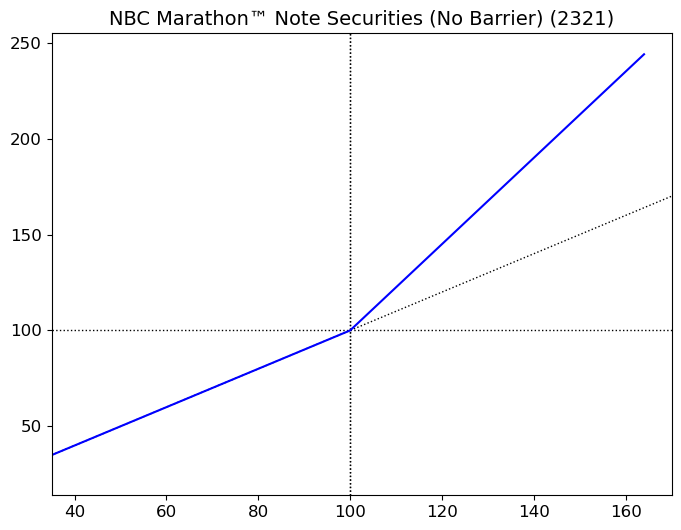

In [18]:

K = S_0
H = (1-0.0)*S_0
T = 5
AF = 2.25

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) - (K-H)*DigitalPut(np.nan, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon™ Note Securities (No Barrier) (2321)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

# NBC2542, NBC Marathon™ (Accelerator) Note Securities (Maturity-Monitored Barrier) linked to the Canadian market
 https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=2681


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S    |
    | H< S(T) $\le$ S_0 | S_0    |
    | S(T)>S_0.          | AF*S     |

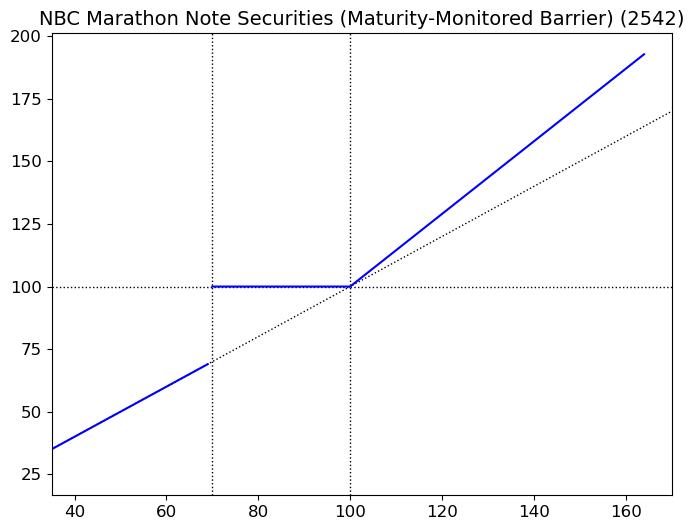

In [19]:

K = S_0
H = (1-0.3)*S_0
T = 5.5
AF = 1.45

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) - (K-H)*DigitalPut(np.nan, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon Note Securities (Maturity-Monitored Barrier) (2542)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position'])
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);

# NBC26740, NBC S&P/TSX Composite Low Volatility Index Deposit Notes 
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=4764


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ S_0  | S_0    |
    | S(T)>S_0.         | AF*S（T）|

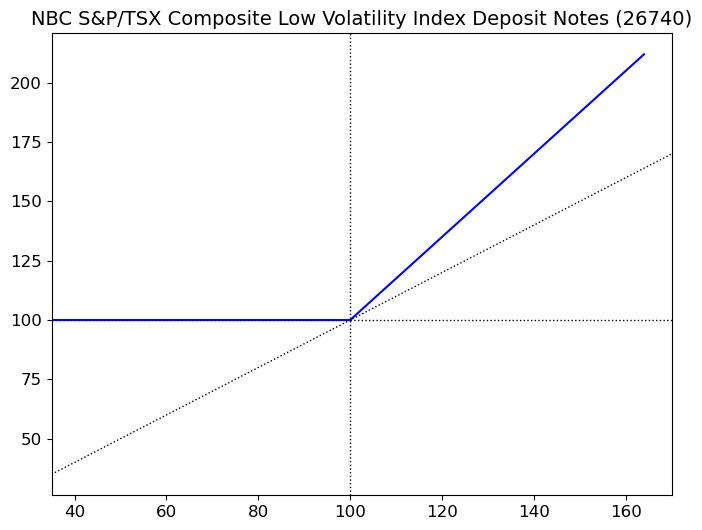

In [20]:

K = S_0
T = 5
AF = 1.75

note = AF*Call(S_0, K) + K*Bond(T) 

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC S&P/TSX Composite Low Volatility Index Deposit Notes (26740)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

# NBC26741, NBC Canadian Market Low Volatility GIC
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=4826

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ S_0  | S_0    |
    | S(T)>S_0.         | AF*S（T）|


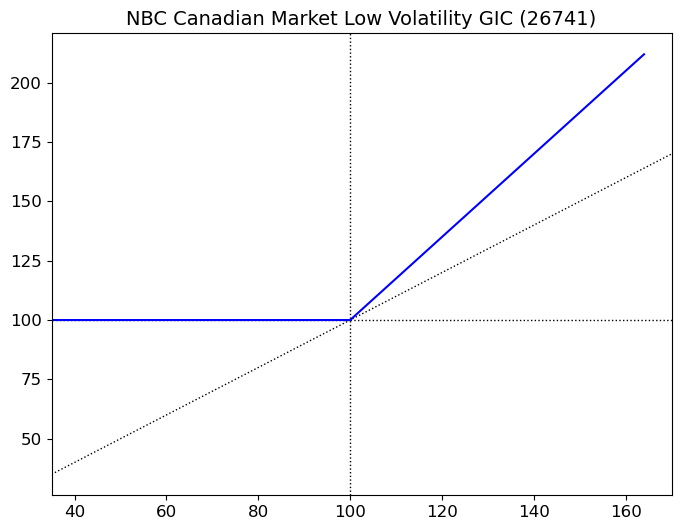

In [21]:

K = S_0
T = 5
AF = 1.75

note = AF*Call(S_0, K) + K*Bond(T) 

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Canadian Market Low Volatility GIC (26741)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

# NBC26742， NBC American companies GIC
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=4779


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ S_0  | S_0    |
    | S_0<S(T)<S_0*(1+MR).         | S（T）|
    | S_0<S(T)>S_0*(1+MR).         | S_0*(1+MR)|

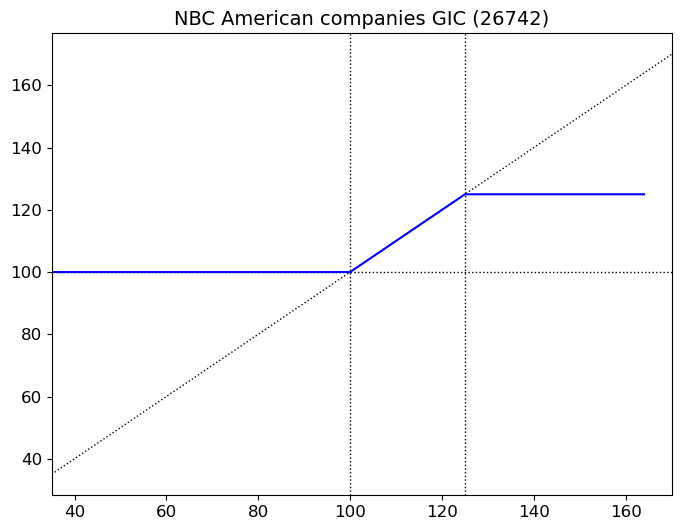

In [22]:

K = S_0
MR = 0.25 # Maximum Variable Return
T = 5
TW = 1

note = Spot(S_0) + Put(S_0, K) - Call(S_0, (1+MR)*K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC American companies GIC (26742)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline((1+MR)*K, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

# NBC26743
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=4827


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ S_0  | S_0    |
    | S(T)>S_0.         | PF*S（T）|


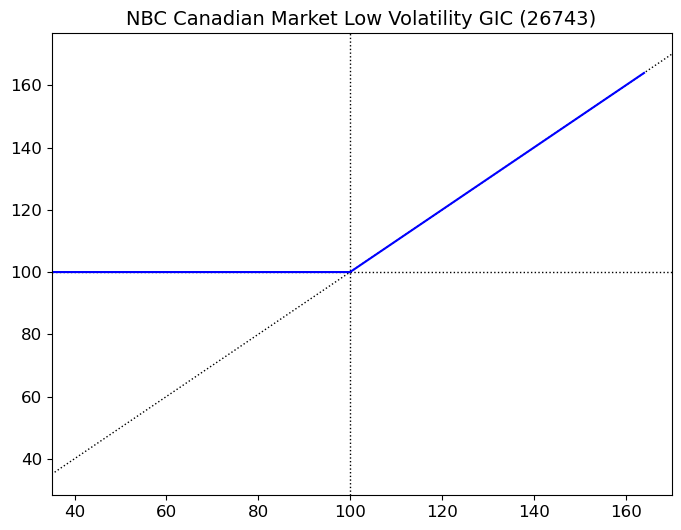

In [23]:

K = S_0
T = 2.5
PF = 1

note = Spot(S_0) + PF*Put(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Canadian Market Low Volatility GIC (26743)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

# NBC26744  NBC S&P/TSX Composite Low Volatility Index with Low Point Deposit Notes (USD)
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=4784
# NBC26745 NBC26790 NBC26799 NBC26804
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=4785
# NBC26745 Return from low point over first 9 months (observed daily)
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=4823
# NBC26813 NBC26819 NBC26825 NBC26830 NBC26832 NBC26834 NBC26837 NBC26838

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ Initial level (lowest point)    | S_0    |
    | S(T)>Initial level (lowest point).         | S_0*max(0, (S-Lowest price))/Lowest price |


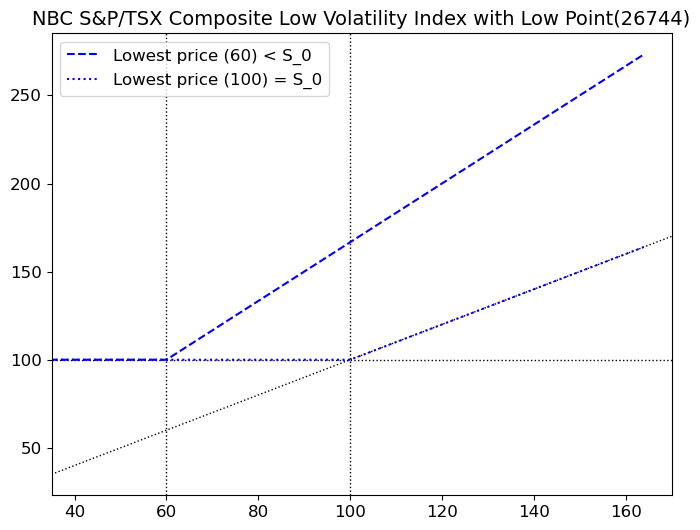

In [24]:
K_1 = 0.6*S_0
K_2 = S_0
T = 6
PF = 1

note_1 = (K_2/K_1)*Spot(S_0) + (K_2/K_1)*Put(S_0, K_1) + (PF-1) *(K_2/K_1)*Call(S_0, K_1) 
note_2 = Spot(S_0) + Put(S_0, K_2) + (PF-1)*Call(S_0, K_2)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC S&P/TSX Composite Low Volatility Index with Low Point(26744)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K_1, **styles['gridlines'])
ax.axvline(K_2, **styles['gridlines'])

payoff_1 = note_1.payoff(S_T) 
payoff_2 = note_2.payoff(S_T) 

ax.plot(S_T, payoff_1, **with_style('Lowest price (60) < S_0', 'position1')) 
ax.plot(S_T, payoff_2, **with_style('Lowest price (100) = S_0', 'position2')) 

ax.legend(loc='upper left');
ax.set_xlim(xlims);

# NBC26746, NBC Canadian Market Low Volatility Flex GIC
 https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=4799 
# 26747
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=4810


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ S_0  | S_0    |
    | S(T)>S_0.         | S（T）|



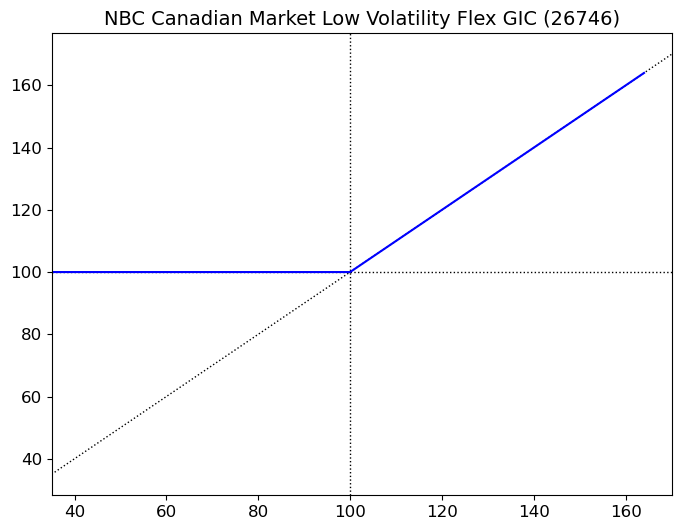

In [25]:

K = S_0
T = 2.5
PF = 1

note = Spot(S_0) + PF*Put(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Canadian Market Low Volatility Flex GIC (26746)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

# NBC26779 NBC Canadian Market Low Volatility with Low Point Flex
 https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=5010

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ Initial level (lowest point)    | S_0    |
    | S(T)>Initial level (lowest point).         | S_0\*participation factor\*max(0, (S-Lowest price))/Lowest price |


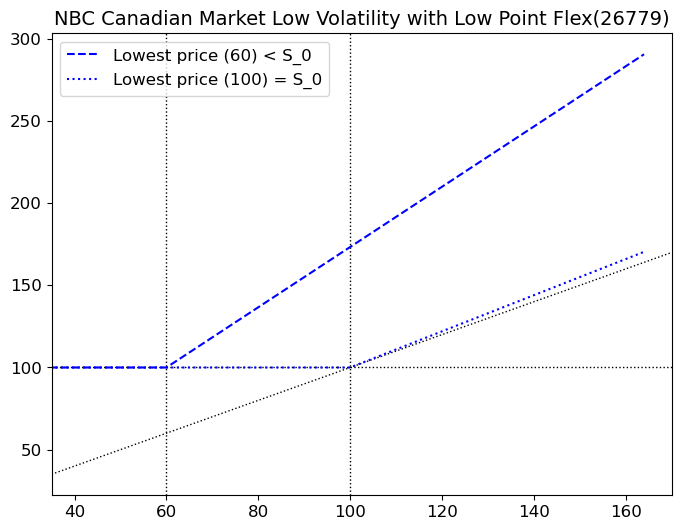

In [26]:

K_1 = 0.6*S_0
K_2 = S_0
T = 6.5
PF = 1.1

note_1 = (K_2/K_1)*Spot(S_0) + (K_2/K_1)*Put(S_0, K_1) + (PF-1) *(K_2/K_1)*Call(S_0, K_1) 
note_2 = Spot(S_0) + Put(S_0, K_2) + (PF-1)*Call(S_0, K_2)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Canadian Market Low Volatility with Low Point Flex(26779)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K_1, **styles['gridlines'])
ax.axvline(K_2, **styles['gridlines'])

payoff_1 = note_1.payoff(S_T) 
payoff_2 = note_2.payoff(S_T) 

ax.plot(S_T, payoff_1, **with_style('Lowest price (60) < S_0', 'position1')) 
ax.plot(S_T, payoff_2, **with_style('Lowest price (100) = S_0', 'position2')) 

ax.legend(loc='upper left');
ax.set_xlim(xlims);

# NBC26808 NBC Canadian Market Low Volatility with Low Point Flex GIC
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=5235

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ Initial level (lowest point)    | S_0    |
    | S(T)>Initial level (lowest point).         | S_0\*participation factor\*max(0, (S-Lowest price))/Lowest price |


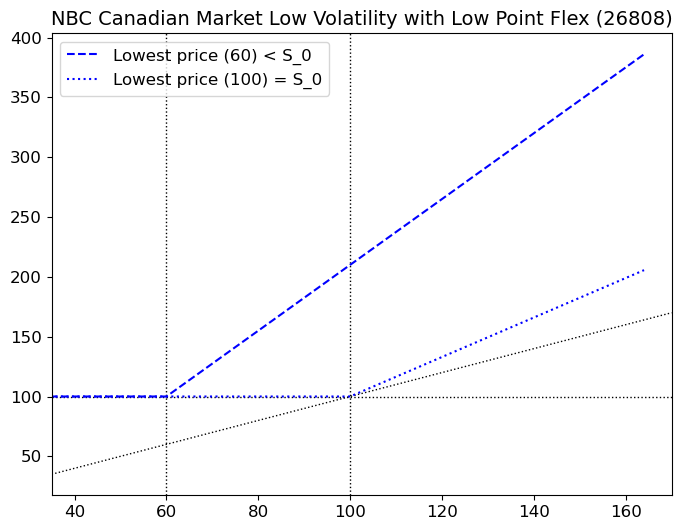

In [27]:
# NBC26808
# https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=5235
# Return from low point over first 9 months (observed daily)
# Participation Factor: 165%

K_1 = 0.6*S_0
K_2 = S_0
T = 8
PF = 1.65

note_1 = (S_0/K_1)*Spot(S_0) + (S_0/K_1)*Put(S_0, K_1) + (PF-1)*(S_0/K_1)*Call(S_0, K_1) 
note_2 = Spot(S_0) + Put(S_0, K_2) + (PF-1)*Call(S_0, K_2)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Canadian Market Low Volatility with Low Point Flex (26808)')
plot_underlying()
ax.axhline(K_2, **styles['gridlines'])
ax.axvline(K_1, **styles['gridlines'])
ax.axvline(K_2, **styles['gridlines'])

payoff_1 = note_1.payoff(S_T) 
payoff_2 = note_2.payoff(S_T) 

ax.plot(S_T, payoff_1, **with_style('Lowest price (60) < S_0', 'position1')) 
ax.plot(S_T, payoff_2, **with_style('Lowest price (100) = S_0', 'position2')) 

ax.legend(loc='upper left');
ax.set_xlim(xlims);

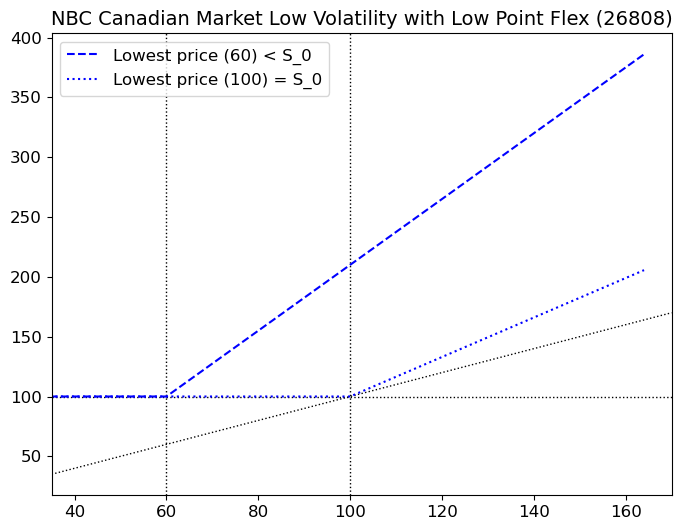

In [28]:
# NBC26808
# https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=5235
# Return from low point over first 9 months (observed daily)
# Participation Factor: 165%
# Christian's version
K_1 = 0.6*S_0
K_2 = S_0
T = 5
PF = 1.65

payoff = []
forward_start = "S_0*Bond(T) + (S_0/S_t0)*PF*Call(S_t0, S_t0)"
for S_t0 in [K_1, K_2]:
    note = eval(forward_start)
    payoff.append( note.payoff(S_T) )

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Canadian Market Low Volatility with Low Point Flex (26808)')
plot_underlying()
ax.axhline(S_0, **styles['gridlines'])
ax.axvline(K_1, **styles['gridlines'])
ax.axvline(K_2, **styles['gridlines'])

ax.plot(S_T, payoff[0], **with_style('Lowest price (60) < S_0', 'position1')) 
ax.plot(S_T, payoff[1], **with_style('Lowest price (100) = S_0', 'position2')) 

ax.legend(loc='upper left');
ax.set_xlim(xlims);

# NBC25227, NBC Marathon™ (Accelerator) Note Securities (Maturity-Monitored Barrier) linked to the Canadian market,
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=5475

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S    |
    | H< S(T) $\le$ S_0 | S_0    |
    | S(T)>S_0.          | AF*S     |

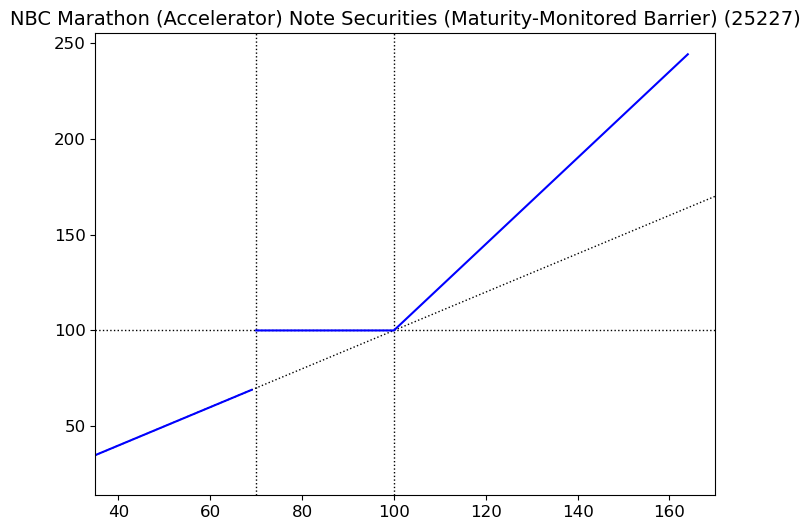

In [29]:

K = S_0
H = (1-0.3)*S_0
T = 5
AF = 2.25

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) - (K-H)*DigitalPut(np.nan, H) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon (Accelerator) Note Securities (Maturity-Monitored Barrier) (25227)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position']) # highlight the discontinuity
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);

# NBC25230, NBC Marathon™ (Accelerator) Note Securities (No Barrier) linked to the Canadian market

https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=5476

* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ S_0    | S    |
    | S(T)>S_0.          | AF*S     |


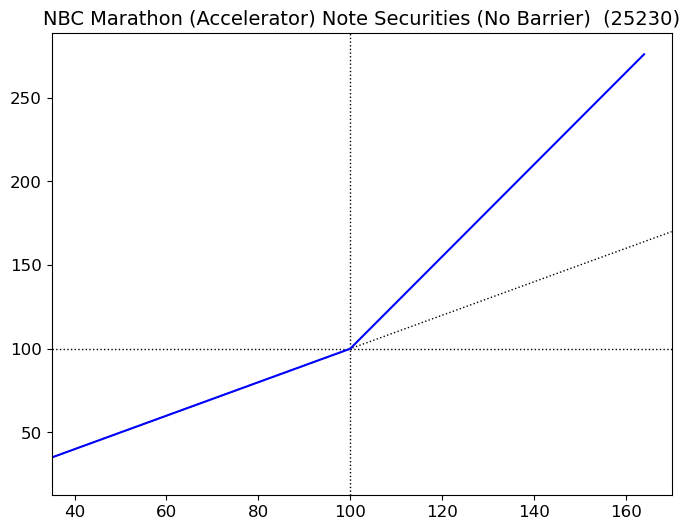

In [30]:
K = S_0
T = 5
AF = 2.75

note = Spot(S_0) + (AF-1)*Call(S_0, K)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Marathon (Accelerator) Note Securities (No Barrier)  (25230)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T, payoff, **styles['position']);
ax.set_xlim(xlims);

## NBC20283, NBC Fixed Coupon Note Securities (Maturity-Monitored Barrier) linked to the Canadian market
https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=5590


* Payoff table: 

    | Terminal value   | Payoff |
    |------------------|--------|
    | S(T) $\le$ H     | S + coupon   |
    | H< S(T) $\le$ S_0 | S_0  + coupon  |
    | S(T)>S_0.          | S+PF*(S-S_0) + coupon    |

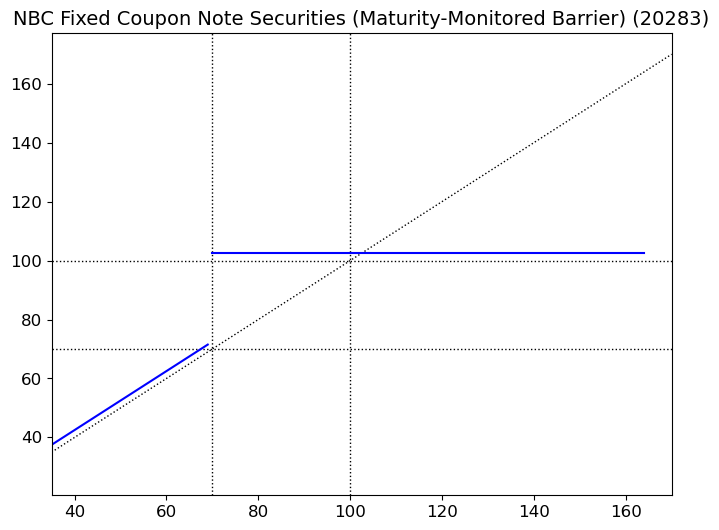

In [31]:
# NBC20283
# https://nbcstructuredsolutions.ca/detailProduit.aspx?lequel=5590
H = (1-0.30)*S_0
T = 6
PF = 0
RT = 0
K = S_0
ROC = 2.5

note = Spot(S_0) + Put(S_0, K) - Put(S_0, H) - (K-H)*DigitalPut(np.nan, H) + (PF-1)*Call(S_0, K) + ROC*Bond(T)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
plt.title('NBC Fixed Coupon Note Securities (Maturity-Monitored Barrier) (20283)')
plot_underlying()
ax.axhline(K, **styles['gridlines'])
ax.axhline(H, **styles['gridlines'])
ax.axvline(K, **styles['gridlines'])
ax.axvline(H, **styles['gridlines'])

payoff = note.payoff(S_T) 
ax.plot(S_T[S_T<=H], payoff[S_T<=H], **styles['position']) # highlight the discontinuity
ax.plot(S_T[S_T>H], payoff[S_T>H], **styles['position']);
ax.set_xlim(xlims);